In [1]:
import sys
from pathlib import Path
ROOT = Path.cwd().parents[0] if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))

import matplotlib.pyplot as plt
from omegaconf import OmegaConf
from src.finetune import ensure_cyrillic, load_iam, TsvLineDataset, HFLineDataset

cfg = OmegaConf.load(ROOT / "configs" / "finetune.yaml")

In [2]:
def show(dataset, n=6, title=""):
    fig, axes = plt.subplots(n, 1, figsize=(12, 1.4 * n))
    for ax, i in zip(axes, range(n)):
        s = dataset[i]
        ax.imshow(s["image"]); ax.axis("off")
        ax.set_title(s["text"], fontsize=10, loc="left")
    fig.suptitle(title); plt.tight_layout(); plt.show()

cyrillic train/test: 72284 1544


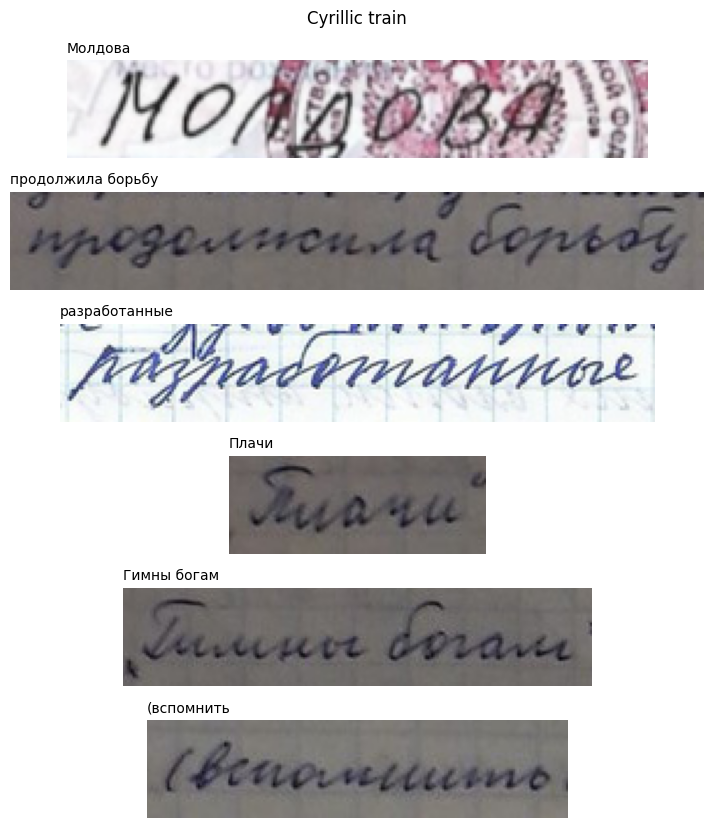

In [3]:
cyr = ensure_cyrillic(ROOT / cfg.data.cyrillic_root)
cyr_train = TsvLineDataset(cyr.train_tsv, cyr.root, "train")
cyr_test = TsvLineDataset(cyr.test_tsv, cyr.root, "test")
print("cyrillic train/test:", len(cyr_train), len(cyr_test))
show(cyr_train, title="Cyrillic train")

Generating train split:   0%|          | 0/6482 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/976 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/2915 [00:00<?, ? examples/s]

iam columns: ['image', 'text']
iam train/test: 6482 2915


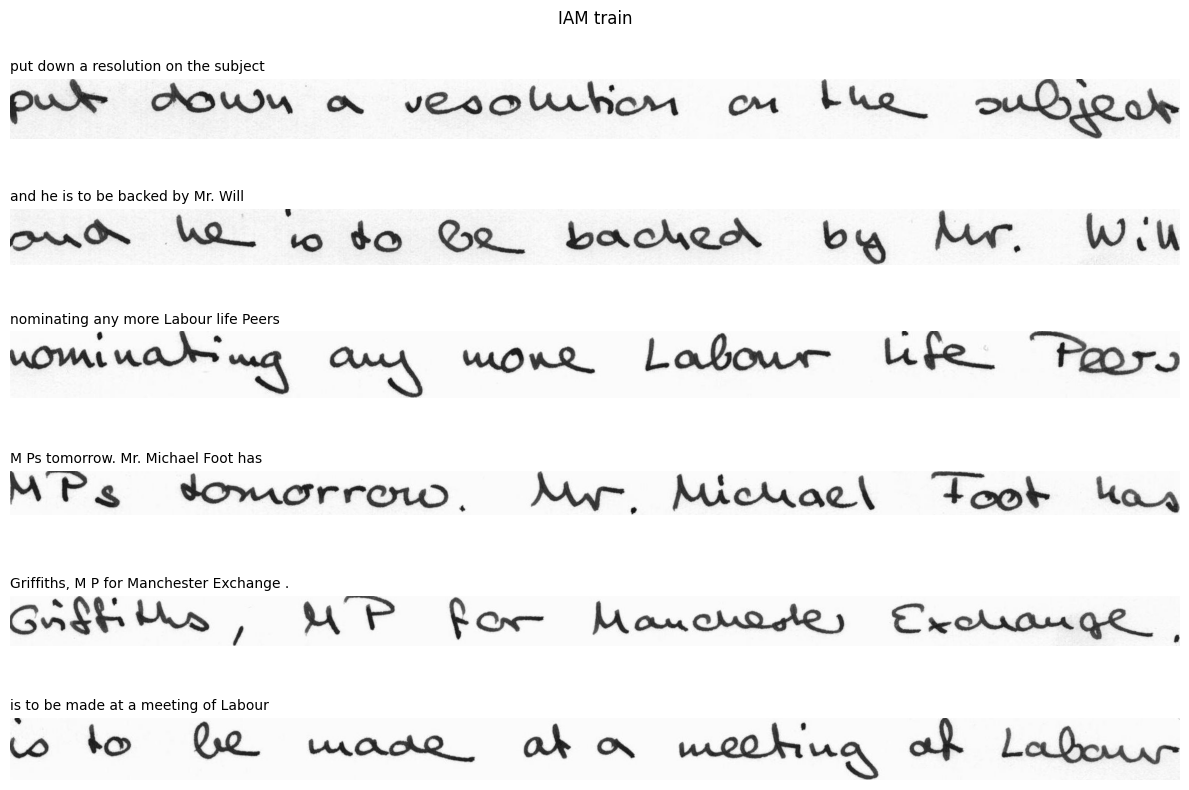

In [4]:
iam = load_iam(cfg.data.get("iam"))
print("iam columns:", iam.train.column_names if iam else None)
print("iam train/test:", len(iam.train), len(iam.test) if iam and iam.test else 0)
if iam:
    show(HFLineDataset(iam.train, iam.image_key, iam.text_key), title="IAM train")